**Text Detection**: https://www.geeksforgeeks.org/python/text-detection-and-extraction-using-opencv-and-ocr/ 

**NER Model**: https://huggingface.co/dslim/bert-base-NER 


In [8]:
import cv2
import os
import matplotlib.pyplot as plt

### **Step 1**: Read images from folder

In [9]:
# Image paths
IMAGES_PATHS = [
    os.path.abspath(os.path.join(os.getcwd(), "images", "I1.png")),
    os.path.abspath(os.path.join(os.getcwd(), "images", "I2.png"))
]

IMAGES_GND_PATHS = [
    os.path.abspath(os.path.join(os.getcwd(), "images", "I1_gnd.png")),
    os.path.abspath(os.path.join(os.getcwd(), "images", "I2_gnd.png"))
]

print("Image paths:")
for i in range(len(IMAGES_PATHS)):
    print(f"Image {i+1}: {IMAGES_PATHS[i]}")
    print(f"Ground Image{i+1}: {IMAGES_GND_PATHS[i]}")

Image paths:
Image 1: /Users/merteldem1r/Documents/GitHub/Computer-Vision-COME370/Project/Solution/images/I1.png
Ground Image1: /Users/merteldem1r/Documents/GitHub/Computer-Vision-COME370/Project/Solution/images/I1_gnd.png
Image 2: /Users/merteldem1r/Documents/GitHub/Computer-Vision-COME370/Project/Solution/images/I2.png
Ground Image2: /Users/merteldem1r/Documents/GitHub/Computer-Vision-COME370/Project/Solution/images/I2_gnd.png


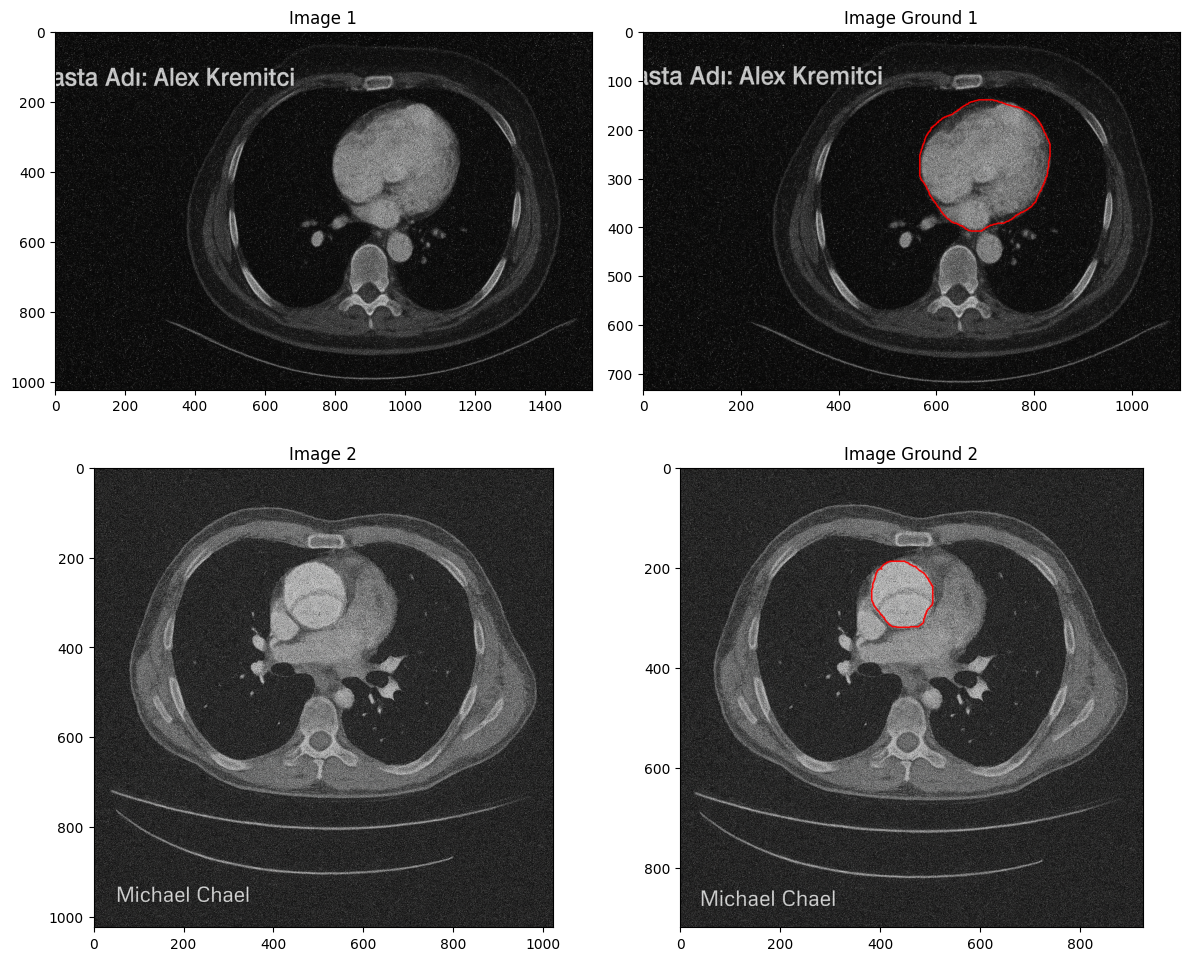

In [10]:
fig, axes = plt.subplots(len(IMAGES_PATHS), 2,
                         figsize=(12, 5*len(IMAGES_PATHS)))

for i in range(len(IMAGES_PATHS)):
    img = cv2.imread(IMAGES_PATHS[i], cv2.IMREAD_COLOR)
    gnd_img = cv2.imread(IMAGES_GND_PATHS[i], cv2.IMREAD_COLOR)

    axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Image {i+1}")

    axes[i, 1].imshow(cv2.cvtColor(gnd_img, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title(f"Image Ground {i+1}")

plt.tight_layout()
plt.show()

### **Step 2**: Preprocess images (helper functions)

In [11]:
PATIENTS_PATH = os.path.abspath(os.path.join(os.getcwd(), "patients"))

In [12]:
import pytesseract

print(pytesseract.get_tesseract_version())

# get the top left (those coorditates are determined by trial and error)


def crop_top_left(img):
    h, w = img.shape[:2]

    x1 = 0
    y1 = 60
    x2 = int(w * 0.45)
    y2 = int(h * 0.18)

    return img[y1:y2, x1:x2]

# get the bottom left


def crop_bottom_left(img):
    h, w = img.shape[:2]

    x1 = 0
    y1 = int(h * 0.90)
    x2 = int(w * 0.40)
    y2 = h - 30

    return img[y1:y2, x1:x2]


def image_preprocess(img: str, position: str) -> cv2.Mat:
    # convert to grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()

    # crop the wanted region
    if position == "top_left":
        gray = crop_top_left(gray)
    elif position == "bottom_left":
        gray = crop_bottom_left(gray)

    # reduce noise
    denoised = cv2.medianBlur(gray, 3)

    # improve local contrast
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)

    return enhanced

5.5.1


### **Step 3**: Process images and extract text

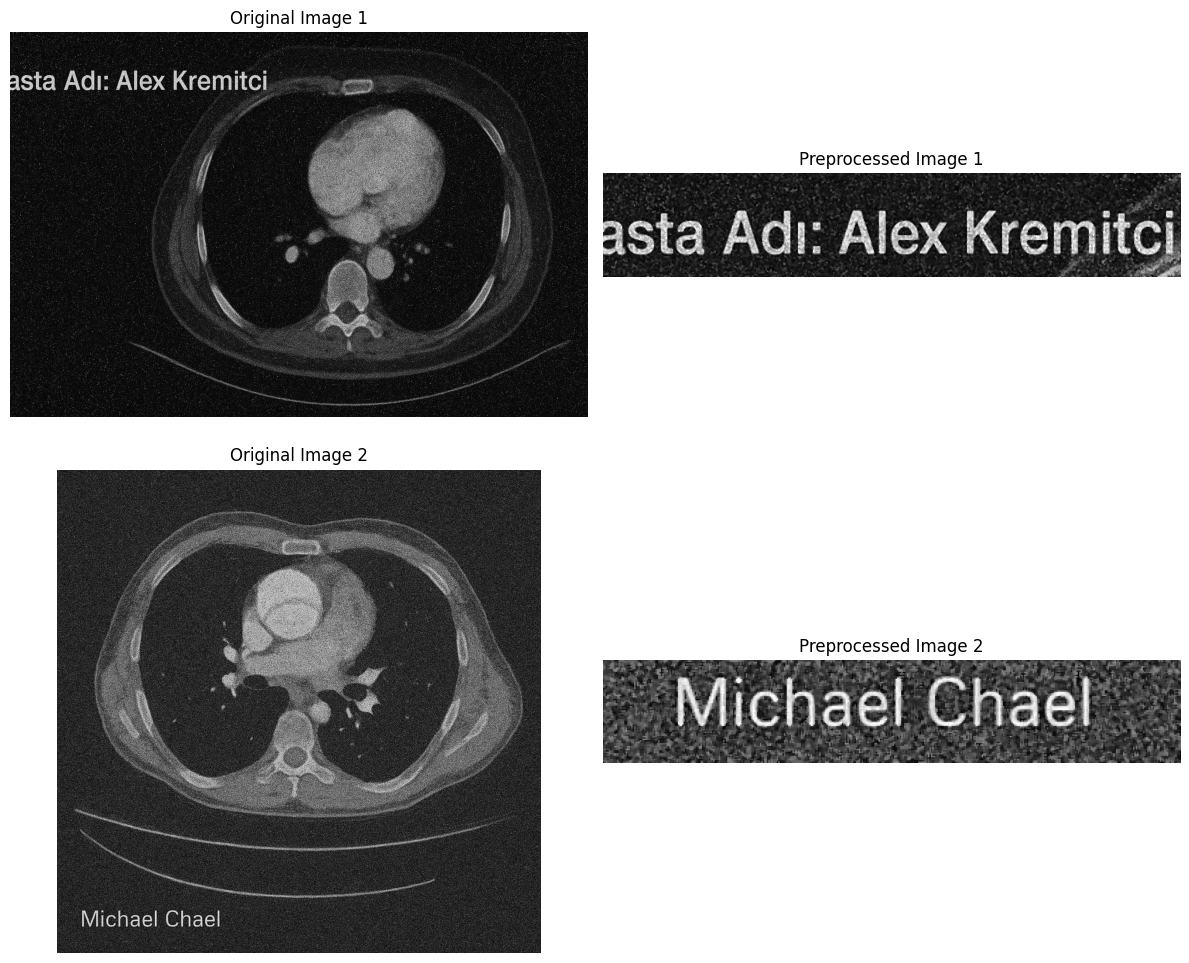

Extracted Text from Image 1: asta Adi: Alex Kremitci

Extracted Text from Image 2: Michael Chael



In [13]:
# read and convert images to graycale and extract text
fig, axes = plt.subplots(len(IMAGES_PATHS), 2,
                         figsize=(12, 5*len(IMAGES_PATHS)))

IMAGE_TEXTS: list[str] = []

for i in range(len(IMAGES_PATHS)):
    # image read & preprocess
    img = cv2.imread(IMAGES_PATHS[i], cv2.IMREAD_COLOR)
    position = "top_left" if i == 0 else "bottom_left"
    preprocessed = image_preprocess(img, position=position)

    # text extraction
    text = pytesseract.image_to_string(preprocessed)
    IMAGE_TEXTS.append(text.strip())

    # display original and preprocessed images
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"Original Image {i+1}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(preprocessed, cmap='gray')
    axes[i, 1].set_title(f"Preprocessed Image {i+1}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# show found text
for i, text in enumerate(IMAGE_TEXTS):
    print(f"Extracted Text from Image {i+1}: {text}\n")

### **Step 4**: Named Entity Recognition (NER) using Hugging face API

In [14]:
import requests
import json
from dotenv import load_dotenv

# Load variables from .env into the environment
load_dotenv()

API_URL = "https://router.huggingface.co/hf-inference/models/dslim/bert-base-NER"
headers = {
    "Authorization": f"Bearer {os.environ.get('HF_TOKEN')}",
}


def query(payload):
    response = requests.post(API_URL, headers=headers, json=payload)
    return response.json()


IMAGE_INFOS: list[dict] = []

for i in range(len(IMAGES_PATHS)):
    output = query({
        "inputs": IMAGE_TEXTS[i],
    })
    IMAGE_INFOS.append({
        "image_path": IMAGES_PATHS[i],
        "image_gnd_path": IMAGES_GND_PATHS[i],
        "extracted_text": IMAGE_TEXTS[i],
        "name_output": output[0]["word"]
    })

print(json.dumps(IMAGE_INFOS, indent=4))

[
    {
        "image_path": "/Users/merteldem1r/Documents/GitHub/Computer-Vision-COME370/Project/Solution/images/I1.png",
        "image_gnd_path": "/Users/merteldem1r/Documents/GitHub/Computer-Vision-COME370/Project/Solution/images/I1_gnd.png",
        "extracted_text": "asta Adi: Alex Kremitci",
        "name_output": "Alex Kremitci"
    },
    {
        "image_path": "/Users/merteldem1r/Documents/GitHub/Computer-Vision-COME370/Project/Solution/images/I2.png",
        "image_gnd_path": "/Users/merteldem1r/Documents/GitHub/Computer-Vision-COME370/Project/Solution/images/I2_gnd.png",
        "extracted_text": "Michael Chael",
        "name_output": "Michael Cha"
    }
]
